In [2]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import IPython.display as ipd
import matplotlib.dates as mdates
#from matplotlib.dates import MO, TU, WE, TH, FR, SA, SU
import matplotlib.ticker as mticker
import datetime as dt
from collections import defaultdict
import plotly.express as ply

Student Acronym: chbh22

CT 1-1:

1: I read and print the first 5 and last 10 entries

2: I take all the dates from the earliest to most recent that can be found in the dataset. I then compare all the dates that exist in that span with the ones that exist in the dataset, filling the gaps with np.nan in the process.

3: The values get sorted

CT 1-2:

1: The chart shows that the lowest point for AMZN is around 5th of August 2024

2: While MSFT has a higher stock evaluation, the chart itself is fairly similar to the dips and highs of AMZN and GOOGL. Generally AAPL, GOOGL, TSLA and AMZN all look similar at the start, however the graphs diverge after around 1st of July. Thereafter, GOOGL and AMZN are similar to each other, and AAPL and TSLA are similar.

3: Frequency of 60 between 220-230

In [3]:
# 1.

df: pd.DataFrame = pd.read_csv('./data/assignment_CaseA_data.csv')

dfList = [df.iloc[0:5], df.iloc[90:100]]

result: pd.DataFrame = pd.concat(dfList)

print(result)

dates = mdates.drange(dt.datetime(2024, 5, 7), dt.datetime(2024, 9, 25), dt.timedelta(days=1))
dates_data = mdates.datestr2num(df['date'])

for date in dates:
    if date not in dates_data:
        df.loc[df.index.max() + 1] = [mdates.num2date(date).strftime('%Y-%m-%d'), np.nan, np.nan, np.nan, np.nan, np.nan]

df['date'] = pd.to_datetime(df['date'])
df['AAPL'] = pd.to_numeric(df['AAPL'])
df['MSFT'] = pd.to_numeric(df['MSFT'])
df['GOOGL'] = pd.to_numeric(df['GOOGL'])
df['TSLA'] = pd.to_numeric(df['TSLA'])
df['AMZN'] = pd.to_numeric(df['AMZN'])

df.sort_values(by=['date'], inplace=True)
date_data = mdates.date2num(df['date'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(df)

df = df.interpolate(method='linear', inplace=True)
aapl_data = df['AAPL']
msft_data = df['MSFT']
googl_data = df['GOOGL']
amzn_data = df['AMZN']
tsla_data = df['TSLA']

          date    AAPL    MSFT   GOOGL    AMZN    TSLA
0   2024-08-21  226.40  424.14  165.85  180.11  223.27
1   2024-06-18  214.29  446.34  175.09  182.81  184.86
2   2024-07-11  227.57  454.70  185.57  195.05  241.03
3   2024-06-20  209.68  445.70  176.30  186.10  181.57
4   2024-08-28  226.49  410.60  162.85  170.80  205.75
90  2024-08-15  224.72  421.03  161.30  177.59  214.14
91  2024-07-24  218.54  428.90  172.63  180.83  215.99
92  2024-05-15  189.72  423.08  172.51  185.99  173.99
93  2024-05-16  189.84  420.99  174.18  183.63  174.84
94  2024-06-27  214.10  452.85  185.41  197.85  197.42
95  2024-05-08  182.74  410.54  169.38  188.00  174.72
96  2024-09-24  227.37  429.17  162.29  193.96  254.27
97  2024-09-03  222.77  409.44  157.36  176.25  210.60
98  2024-08-29  229.79  413.12  161.78  172.12  206.28
99  2024-07-12  230.54  453.55  185.07  194.49  248.23
          date    AAPL    MSFT   GOOGL    AMZN    TSLA
22  2024-05-07  182.40  409.34  171.25  188.76  177.81
95  2024-0

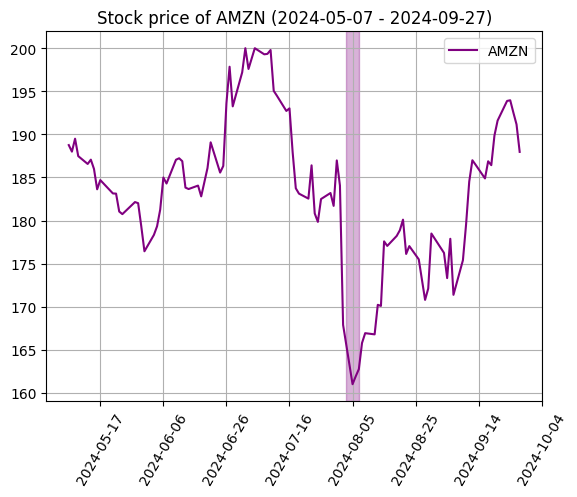

In [4]:
ax = plt.gca()
ax.set_facecolor('white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=60)
ax.x_label = 'Date'
ax.y_label = 'Stock price (Dollar USD)'
plt.grid()

plt.axvspan(*mdates.datestr2num(['2024-08-03', '2024-08-07']), color='purple', alpha=0.3)
plt.plot(date_data, amzn_data, color='purple', label='AMZN')
plt.title('Stock price of AMZN (2024-05-07 - 2024-09-27)')
plt.legend()
plt.show()


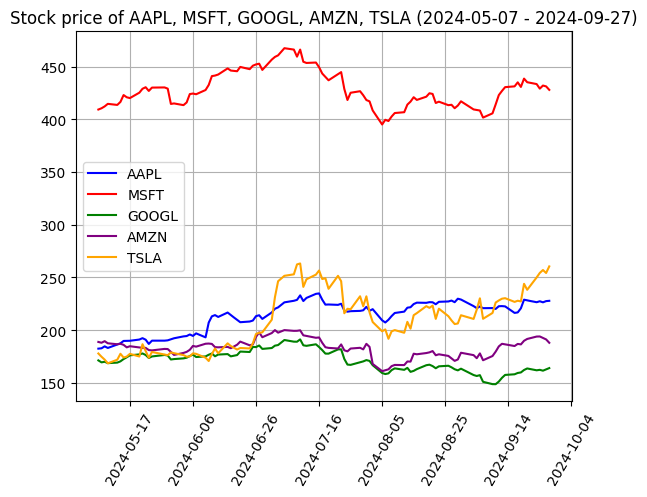

In [5]:
ax = plt.gca()
ax.set_facecolor('white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=60)
ax.x_label = 'Date'
ax.y_label = 'Stock price (Dollar USD)'
plt.grid()

plt.plot(date_data, aapl_data, color='blue', label='AAPL')
plt.plot(date_data, msft_data, color='red', label='MSFT')
plt.plot(date_data, googl_data, color='green', label='GOOGL')
plt.plot(date_data, amzn_data, color='purple', label='AMZN')
plt.plot(date_data, tsla_data, color='orange', label='TSLA')
plt.title('Stock price of AAPL, MSFT, GOOGL, AMZN, TSLA (2024-05-07 - 2024-09-27)')
plt.legend()
plt.show()


234.82


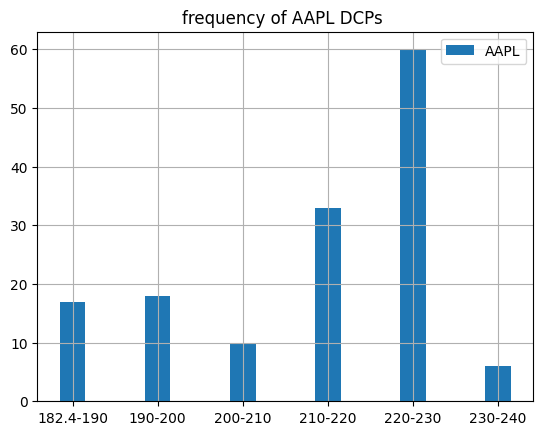

In [9]:
ax = plt.gca()
ax.set_facecolor('white')
ax.x_label = 'Stock price (Dollar USD)'
ax.y_label = 'Frequency of DCP'
plt.grid()

bucket: defaultdict = defaultdict(lambda: 0)
for num in aapl_data:

    if num is np.nan:
        continue

    num = math.floor(num / 10) * 10

    bucket[num] += 1

keys = list(bucket.keys())
vals = bucket.values()

print(max(aapl_data))

plt.bar(keys, vals, label='AAPL', width=3.0)
plt.xticks(keys, ['182.4-190', '190-200', '200-210', '210-220', '220-230', '230-234.82'])
plt.title('frequency of AAPL DCPs ')
plt.legend()
plt.show()


CT 2-1:

1. Ok

2. Ok

3. Ok

4. [2024-05-20, 2024-05-30, 2024-06-16, 2024-06-17, 2024-06-24, 2024-06-25, 2024-06-27...]
My guess is you mean the day TSLA massively increased their stock. The stock price at
2024-06-28 is 197.88

CT 2-2:

1. Ok

2. Ok

3. Ok

4. The average of the stock price between 07-01 and 08-31 for AAPL is 223.242...


In [7]:
date1 = '2024-07-01'
date2 = '2024-08-31'

df2 = df[df['date'] >= pd.to_datetime('2024-07-01')]
df2 = df2[df2['date'] <= pd.to_datetime('2024-08-31')]
aapl_data2 = df2['AAPL']

sum = 0
total_numbers = 0
for num in aapl_data2:
    if num is np.nan:
        continue

    sum += num
    total_numbers += 1

avg = sum / total_numbers
print(avg)


223.24237903225804


In [8]:
out = widgets.Output()

aapl_checkbox = widgets.Checkbox(
    value =  False,
    description = 'AAPL',
    disabled = False
)

msft_checkbox = widgets.Checkbox(
    value =  False,
    description = 'MSFT',
    disabled = False
)

googl_checkbox = widgets.Checkbox(
    value = False,
    description = 'GOOGL',
    disabled = False
)

amzn_checkbox = widgets.Checkbox(
    value = True,
    description = 'AMZN',
    disabled = False
)

tsla_checkbox = widgets.Checkbox(
    value = True,
    description = 'TSLA',
    disabled = False
)

def on_change(_):
    with out:
        out.clear_output(wait=True)
        plt.clf()

        plt.gcf().set_figwidth(30)
        #plt.gcf().set_figheight(10)

        ax = plt.gca()
        ax.set_facecolor('white')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', rotation=60)
        ax.x_label = 'Date'
        ax.y_label = 'Stock price (Dollar USD)'
        plt.grid()

        to_plot = []
        to_color = []
        if aapl_checkbox.value:
            plt.plot(date_data, aapl_data, color='blue', label='AAPL')
            to_plot.append('AAPL')
            to_color.append('blue')
        if msft_checkbox.value:
            plt.plot(date_data, msft_data, color='red', label='MSFT')
            to_plot.append('MSFT')
            to_color.append('red')
        if googl_checkbox.value:
            plt.plot(date_data, googl_data, color='green', label='GOOGL')
            to_plot.append('GOOGL')
            to_color.append('green')
        if amzn_checkbox.value:
            plt.plot(date_data, amzn_data, color='purple', label='AMZN')
            to_plot.append('AMZN')
            to_color.append('purple')
        if tsla_checkbox.value:
            plt.plot(date_data, tsla_data, color='orange', label='TSLA')
            to_plot.append('TSLA')
            to_color.append('orange')

        plt.title('Stock price of AAPL, MSFT, GOOGL, AMZN, TSLA (2024-05-07 - 2024-09-27)')
        if aapl_checkbox.value or msft_checkbox.value or googl_checkbox.value or amzn_checkbox.value or tsla_checkbox.value:
            plt.legend()


        plt.savefig('foo.png')
        plt.show()

        fig = ply.line(df, x='date', y=to_plot)
        fig.add_shape(type='line', line_width=2, line_dash='dash', x0='2024-07-01', x1='2024-08-31', y0=avg, y1=avg)
        fig.add_vline('2024-07-01')
        fig.add_vline('2024-08-31')
        fig.show()


on_change(None)

aapl_checkbox.observe(on_change, names='value')
msft_checkbox.observe(on_change, names='value')
googl_checkbox.observe(on_change, names='value')
amzn_checkbox.observe(on_change, names='value')
tsla_checkbox.observe(on_change, names='value')

ipd.display(out, aapl_checkbox, msft_checkbox, googl_checkbox, amzn_checkbox, tsla_checkbox)



Output()

Checkbox(value=False, description='AAPL')

Checkbox(value=False, description='MSFT')

Checkbox(value=False, description='GOOGL')

Checkbox(value=True, description='AMZN')

Checkbox(value=True, description='TSLA')